# 03. Exploratory Data Analysis - Berlin Housing Market

**Objective**
Explore patterns in Berlin rental prices, districts, apartment sizes and trends over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

rentals = pd.read_csv('../data/processed/rentals_cleaned.csv')
rentals['date_listed'] = pd.to_datetime(rentals['date_listed'])

print("Cleaned data loaded successfully")
print("Shape:", rentals.shape) 

Cleaned data loaded successfully
Shape: (30000, 23)


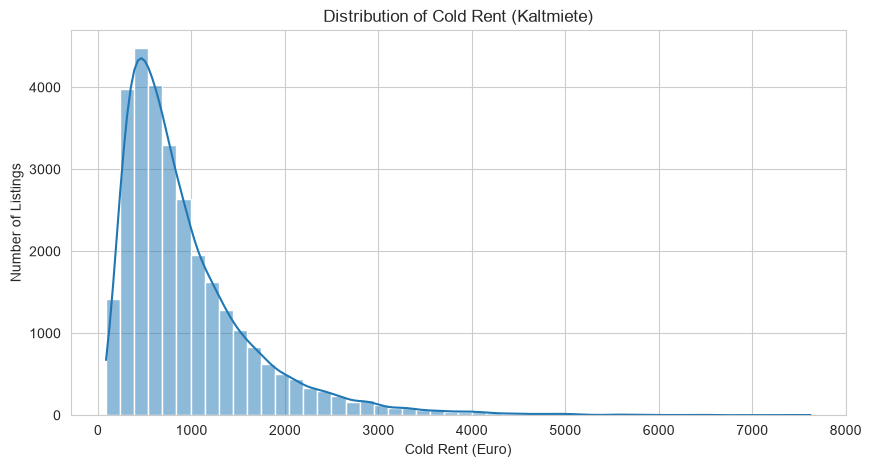

Average cold rent: Euro 946.8
Median cold rent: Euro 735.0


In [6]:
# Overall Rent Distribution

plt.figure(figsize=(10,5))
sns.histplot(rentals['kaltmiete_eur_monthly'], bins=50, kde=True)
plt.title('Distribution of Cold Rent (Kaltmiete)')
plt.xlabel('Cold Rent (Euro)')
plt.ylabel('Number of Listings')
plt.show()

print("Average cold rent: Euro", round(rentals['kaltmiete_eur_monthly'].mean(), 2))
print("Median cold rent: Euro", round(rentals['kaltmiete_eur_monthly'].median(), 2)) 


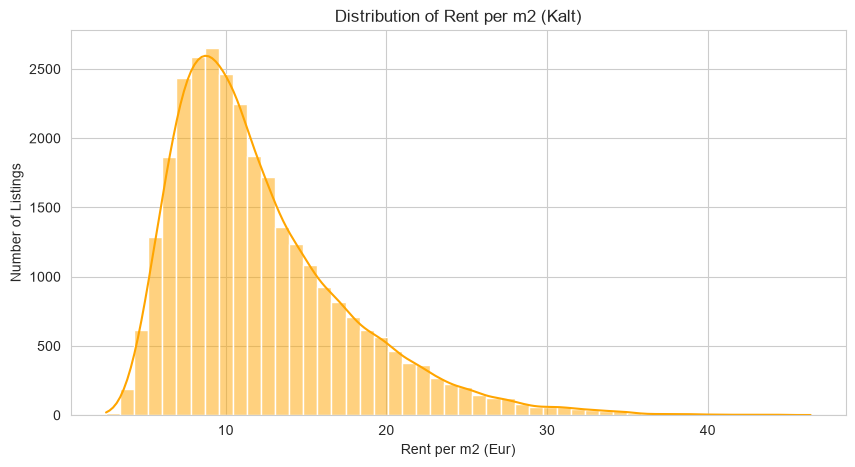

Average rent per m2: Eur 12.12


In [7]:
# Rent per m2 Distribution

plt.figure(figsize=(10,5))
sns.histplot(rentals['rent_per_m2_kalt_eur'], bins=50, kde=True, color='orange')
plt.title('Distribution of Rent per m2 (Kalt)')
plt.xlabel('Rent per m2 (Eur)')
plt.ylabel('Number of Listings')
plt.show()

print("Average rent per m2: Eur", round(rentals['rent_per_m2_kalt_eur'].mean(), 2))

C:\Users\HP\AppData\Local\Temp\ipykernel_1356\2784937855.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_rent.values, y=district_rent.index, palette='viridis')


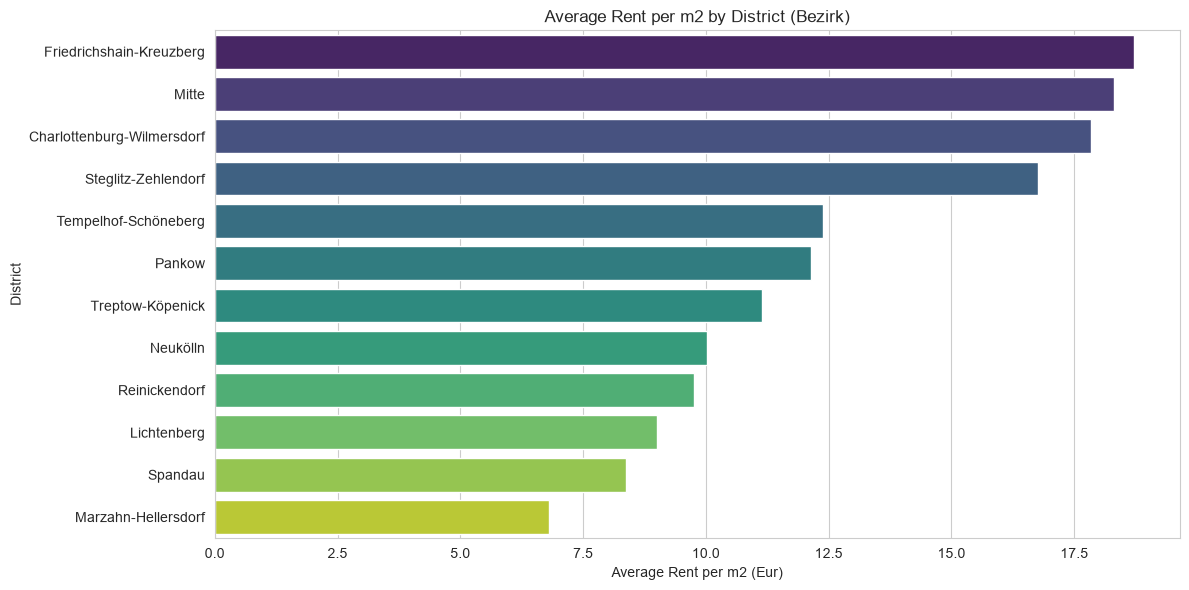

In [9]:
# Average Rent by District

district_rent = rentals.groupby('bezirk')['rent_per_m2_kalt_eur'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=district_rent.values, y=district_rent.index, palette='viridis')
plt.title('Average Rent per m2 by District (Bezirk)')
plt.xlabel('Average Rent per m2 (Eur)')
plt.ylabel('District')
plt.tight_layout()
plt.show()


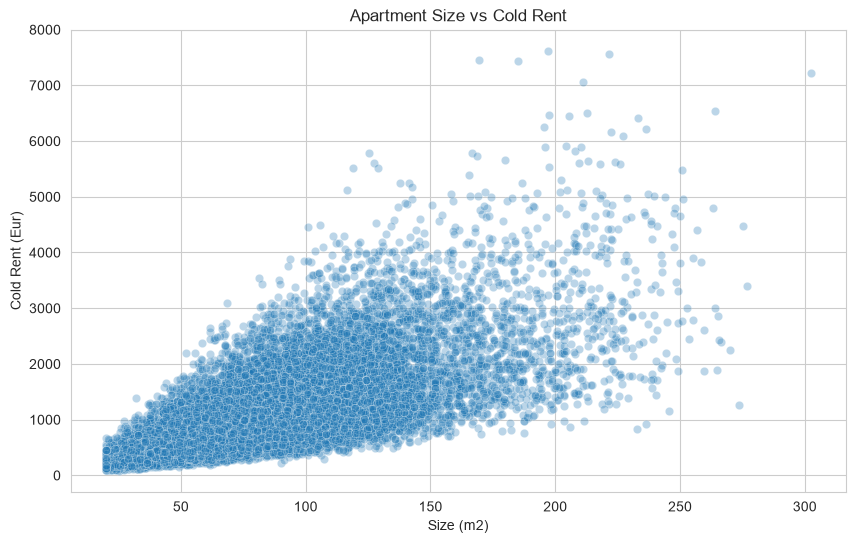

In [10]:
# Size vs Rent

plt.figure(figsize=(10,6))
sns.scatterplot(data=rentals, x='area_m2', y='kaltmiete_eur_monthly', alpha=0.3)
plt.title('Apartment Size vs Cold Rent')
plt.xlabel('Size (m2)')
plt.ylabel('Cold Rent (Eur)')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1356\2771132697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_rent.index, y=room_rent.values, palette='Blues_d')


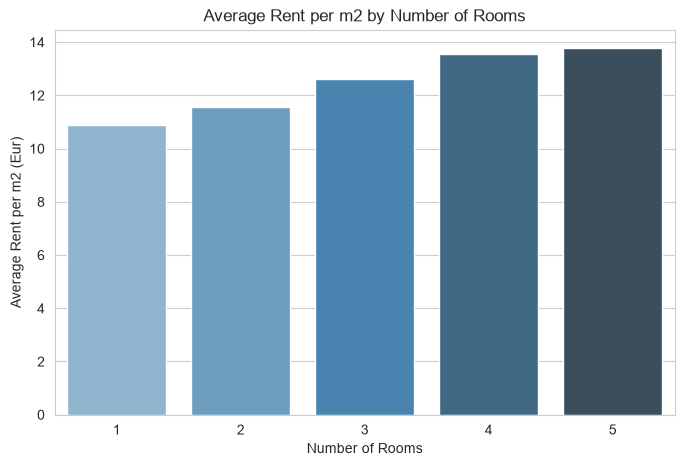

In [13]:
#Average Rent per m2 by Number of Rooms

room_rent = rentals.groupby('rooms')['rent_per_m2_kalt_eur'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=room_rent.index, y=room_rent.values, palette='Blues_d')
plt.title('Average Rent per m2 by Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Average Rent per m2 (Eur)')
plt.show()


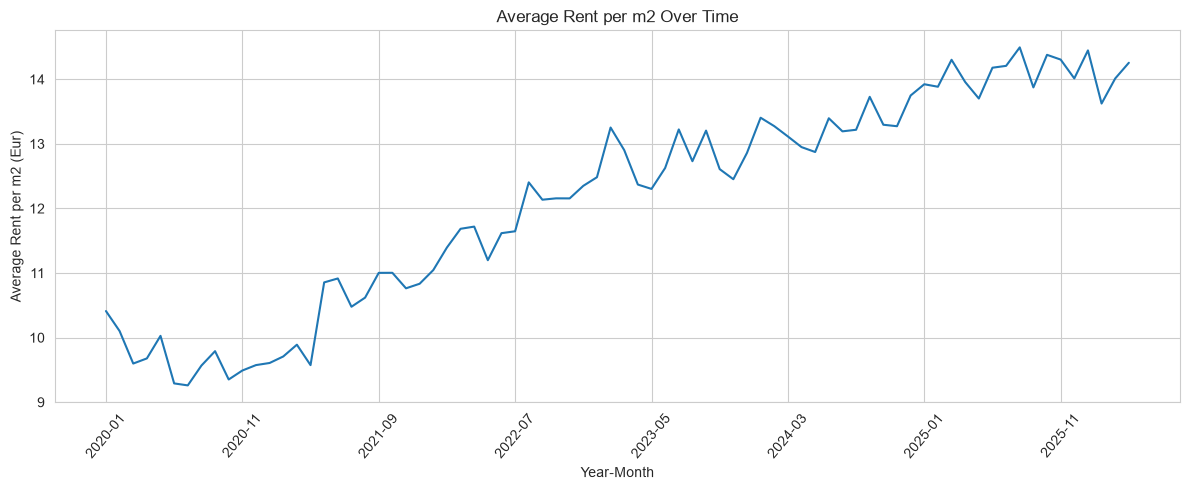

In [16]:
# Rent Trend Over Time

monthly_rent= rentals.groupby('year_month')['rent_per_m2_kalt_eur'].mean()

plt.figure(figsize=(12,5))
monthly_rent.plot()
plt.title('Average Rent per m2 Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Rent per m2 (Eur)')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1356\314038918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='Reds_r')


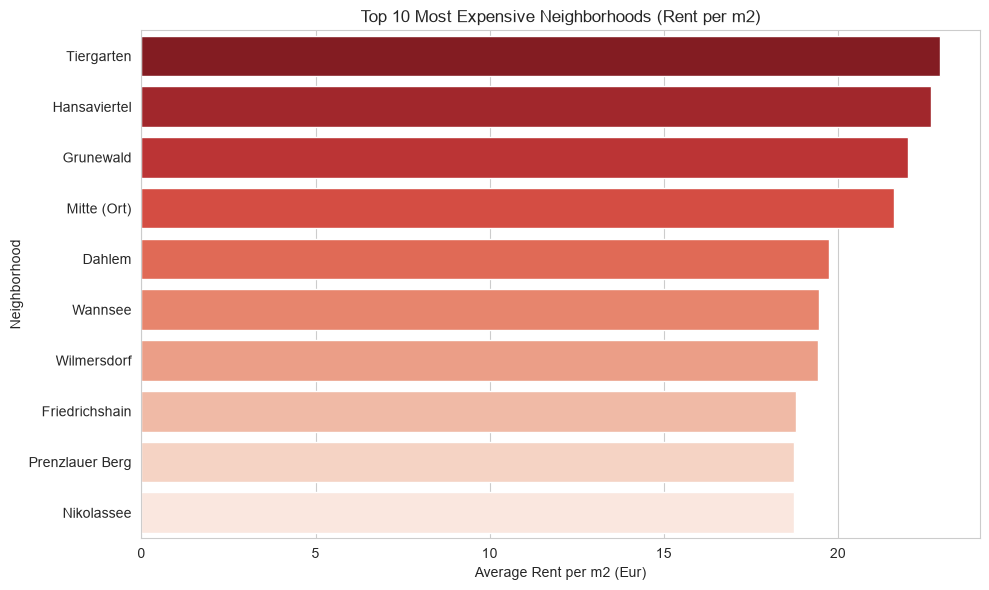

In [18]:
# Top 10 most expensive neighborhoods (Ortsteil)

top_neighborhoods= rentals.groupby('ortsteil')['rent_per_m2_kalt_eur'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='Reds_r')
plt.title('Top 10 Most Expensive Neighborhoods (Rent per m2)')
plt.xlabel('Average Rent per m2 (Eur)')
plt.ylabel ('Neighborhood')
plt.tight_layout()
plt.show()


### Key Insights from EDA
- Average cold rent is around 947 eur with an average size of 76m2.
- Average rent per m2 is app 12.12 eur and has risen above 14 eur by late 2025.
- Friedrichshain-Kreuzberg has the highest average rent among districts.
- Smaller apartments tend to have higher rent per square meter.
- Rental prices in Berlin have shown a clear upward trend over the years.